# Image loading and visualization

This notebook demonstrates how to create, inspect, and visualize detector images using the `ImageCreator`
task and the `DetImage` datamodel. It shows typical workflows: loading raw FITS, inspecting outputs,
combining detectors into a focal plane, and creating a master bias. Each section contains a brief
explanation and the minimal example code you need to reproduce the step.

Imports and setup
 - Import only what is needed for the examples below.
 - Ensure your `PYTHONPATH` includes the project root (or install the package) so imports resolve.
 - Replace the example file paths with paths valid on your machine.

## Example 1: Create images from raw files

Use `ImageCreator` task to convert raw FITS input into high-level `DetImage` objects.

Initializing `ImageCreator` requires a path to a detector configuration file that defines the structure of the raw data and how to parse it.
- Pass a `detector_config` to `ImageCreator` (path to a YAML/JSON file or a Python `dict`) to describe detector geometry and per-output metadata.
- The detector config controls:
  - mapping of data in FITS extensions to detector/outputs of a detector,
  - per-output information and metadata depending on the detector type, e.g. prescan/overscan slices,
  - focal-plane placement

The `run` method of `ImageCreator` accepts the raw data input and produces a dictionary of `DetImage` objects.
- `input_source` accepts a single file, list of files, directory, or glob pattern, OR arrays from buffer
- Optionally provide `identifier_func` to control how files are classified (bias, object, flat, ...)
- Optionally provide `fitsloader_func` to control how raw FITS files are read-in and add custom preprocessing logic
- The return value is a dictionary keyed by image type (e.g. `'object'`, `'bias'`) whose values are lists
  of `DetImage` objects.

In [2]:
from eregion.tasks.imagegen import ImageCreator
# Initialize the ImageCreator with the detector configuration.
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos.yaml')
res = creator.run(input_source='../data/deimos_raw/d0223_0107_cti.fits.gz')

2026-03-10 13:30:55,600 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos.yaml'
2026-03-10 13:30:55,600 - image_creator - INFO - Item ../data/deimos_raw/d0223_0107_cti.fits.gz is a regular path string
2026-03-10 13:30:55,601 - utils.io_utils - INFO - Found FITS file ../data/deimos_raw/d0223_0107_cti.fits.gz.
2026-03-10 13:30:55,601 - image_creator - INFO - Processing file ../data/deimos_raw/d0223_0107_cti.fits.gz


`res` maps image type -> list of `DetImage`. Typical checks:
- Print available keys with `res.keys()`.
- Use `res['object'][0]` (or the appropriate key) to retrieve the first image.
- Each `DetImage` exposes `.data` (full image array) and `.outputs` (per-amplifier subframes).

In [8]:
res

{'object': [<datamodels.image.DetImage at 0x11235afd0>,
  <datamodels.image.DetImage at 0x112346250>]}

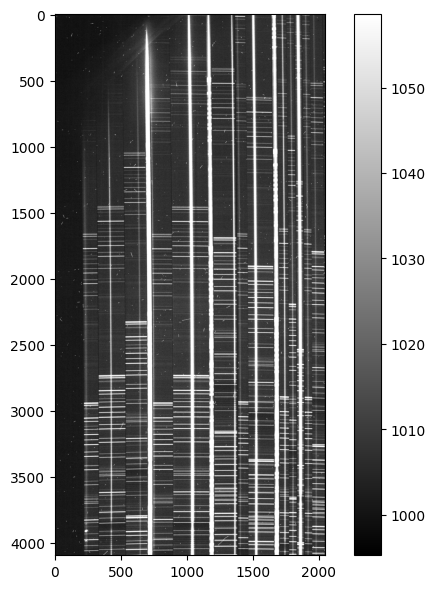

In [8]:
# Display the first DetImage from an input file
det_image = res['object'][0]

# Show the DetImage using its built-in show method that takes kwargs for plt.imshow
# For example, to set the colormap to 'gray', and scale the values using vmin, vmax from ZScaleInterval:
from astropy.visualization import ZScaleInterval
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(det_image.data)
ax = det_image.show(cmap='gray', vmin=vmin, vmax=vmax)

Each `DetImage` contains an `outputs` dict keyed by amplifier id (strings from the detector config).
An `Output` object typically contains:
- `.data`: the amplifier sub-image.
- Detector-type specific attributes like `.serial_prescan`, `.serial_overscan`, `.parallel_prescan`, `.parallel_overscan`: slices you can set or read in `CCDOutput`

In [1]:
det_image.outputs.keys()

NameError: name 'det_image' is not defined

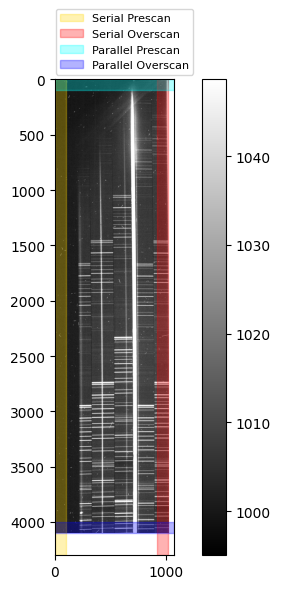

In [10]:
# Plotting the first Output
output = det_image.outputs['chan_1']
vmin, vmax = interval.get_limits(output.data)

# Let's say the serial prescan and overscan regions are first and last 100 columns respectively (only for demo)
# (these are set in the detector config file and can be accessed as attributes of the Output object)
output.serial_prescan = slice(0, 100)
output.serial_overscan = slice(1024-100, 1024)
## Same for parallel prescan and overscan regions, first and last 100 rows respectively
output.parallel_prescan = slice(0, 100)
output.parallel_overscan = slice(4096-100, 4096)
ax = output.show(cmap='gray', vmin=vmin, vmax=vmax, shade_regions=True)

## Building a focal plane image

`FocalPlaneImage` combines multiple `DetImage` instances into a single array representing the focal plane.
- Provide: number of detectors, full dimension, and the list of `DetImage`s.
- The resulting object contains a consolidated `.data` array and a `frames_df` describing detector placement.

The DEIMOS raw FITS used above contains 8 extensions, corresponding to 8 detectors in the focal plane, each detector with two outputs.

The focal plane position information needs to be specified in the detector configuration file.

In [6]:
from eregion.datamodels.image import FocalPlaneImage
fpimage = FocalPlaneImage(num_detectors=8, dim=(4096*2, 2048*4), det_images=res['object'])

In [7]:
# Focal plane usage tips
# - Ensure `num_detectors` and `dim` reflect your detector layout.
# - Use `frames_df` to verify that detector positions were applied correctly.
fpimage.frames_df

,det_id,x_min,x_max,y_min,y_max,y_min_fp,y_max_fp,x_min_fp,x_max_fp
0,det_1,-4096.0,-2048.0,0.0,4096.0,0,4096,0,2048
1,det_2,-2048.0,0.0,0.0,4096.0,0,4096,2048,4096
2,det_3,0.0,2048.0,0.0,4096.0,0,4096,4096,6144
3,det_4,2048.0,4096.0,0.0,4096.0,0,4096,6144,8192
4,det_5,2048.0,4096.0,-4096.0,0.0,4096,8192,6144,8192
5,det_6,0.0,2048.0,-4096.0,0.0,4096,8192,4096,6144
6,det_7,-2048.0,0.0,-4096.0,0.0,4096,8192,2048,4096
7,det_8,-4096.0,-2048.0,-4096.0,0.0,4096,8192,0,2048


<Axes: >

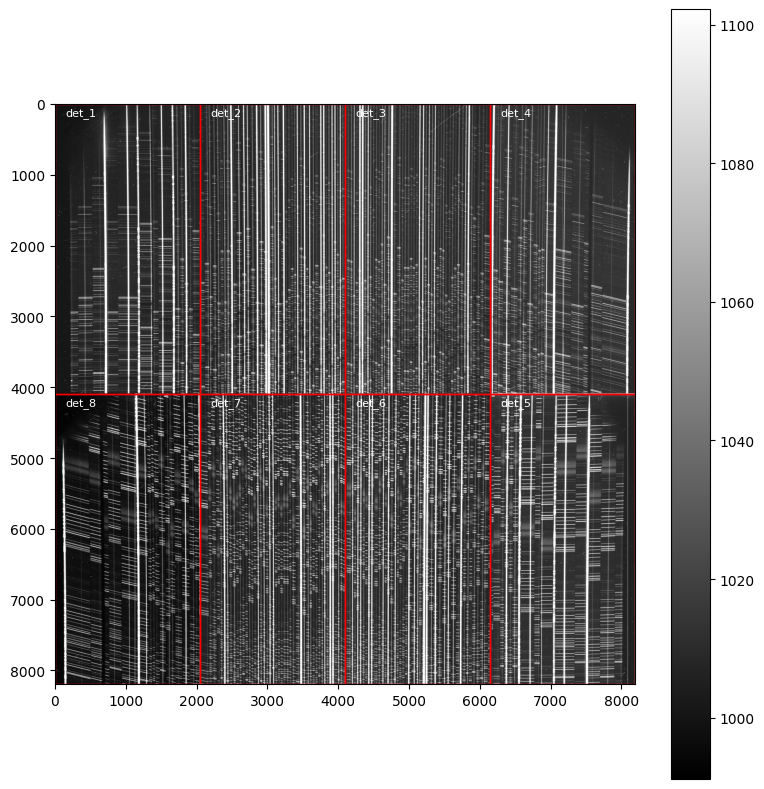

In [8]:
vmin, vmax = interval.get_limits(fpimage.data)
fpimage.show(cmap='gray', vmin=vmin, vmax=vmax)

## Example 2: Image loading with custom identifier function

In [10]:
from eregion.tasks.imagegen import ImageCreator
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_singledet.yaml')

# load custom identifier function to identify bias frames based on filename, supply as identifier_func to ImageCreator.run
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS
res = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_0*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS)

2026-03-09 14:39:50,632 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_singledet.yaml'
2026-03-09 14:39:50,632 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_singledet.yaml'
2026-03-09 14:39:50,632 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_singledet.yaml'
2026-03-09 14:39:50,634 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_0*.fits is a glob pattern
2026-03-09 14:39:50,634 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_0*.fits is a glob pattern
2026-03-09 14:39:50,634 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_0*.fits is a glob pattern
2026-03-09 14

Check the keys in the result to confirm bias images were identified and loaded correctly.

In [11]:
res.keys(), len(res['bias'])

(dict_keys(['bias']), 1)

<Axes: >

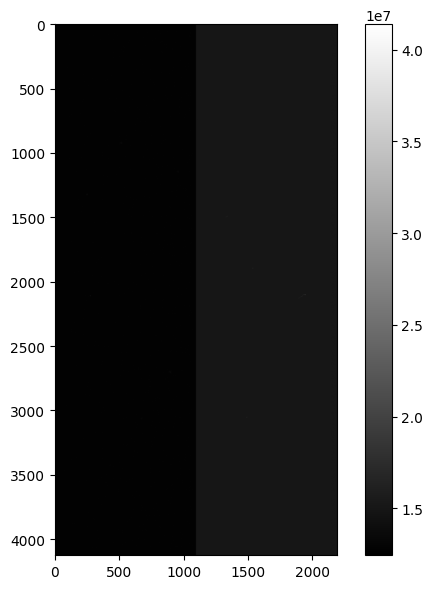

In [12]:
res['bias'][0].show(cmap='gray')

## Example 3: Create master bias using tasks directly in the notebook

In [1]:
from eregion.tasks.imagegen import ImageCreator
from eregion.tasks.calibration import MasterBias
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS

# Create image creator and run it to get bias images
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_singledet.yaml')
res = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS)

2026-03-09 14:49:33,565 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_singledet.yaml'
2026-03-09 14:49:33,566 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/*_bias_*.fits is a glob pattern
2026-03-09 14:49:33,567 - utils.io_utils - INFO - Found FITS file /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/DTU_DT-SCI_2_bias_2_2025-08-12T101455.893.fits.
2026-03-09 14:49:33,567 - utils.io_utils - INFO - Found FITS file /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/DTU_DT-SCI_2_bias_5_2025-08-12T101626.632.fits.
2026-03-09 14:49:33,567 - utils.io_utils - INFO - Found FITS file /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_singledet_acceptance/PTC/SCI/20250812-101350/DTU_DT-SCI_2_bias_4_2025-08-12T10

In [2]:
res.keys(), len(res['bias'])

(dict_keys(['bias']), 10)

Use the `MasterBias` task to combine many bias frames into a single master bias frame.
- Typical method: `'median'` or `'mean'`.
- Input: a list of bias `DetImage` objects, e.g. `res['bias']`.
- Output: a dict (e.g. key `'master_biases'`) containing `DetImage` objects.
- Inspect the result and visualize with the same `show()` helpers.

In [3]:
# To get the list of available methods for any task, use Task.print_methods()
MasterBias().print_methods()

2026-03-09 14:49:39,976 - MasterBias - INFO - Available methods for MasterBias:
2026-03-09 14:49:39,986 - MasterBias - INFO - - median: core.image_operations.median_combine, (images: list[numpy.ndarray]) -> numpy.ndarray


In [4]:
# Create master bias task and run it
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(bias_images=res['bias'])

In [14]:
mb_res

{'master_biases': [<eregion.datamodels.image.DetImage at 0x12a5272f0>]}

<Axes: >

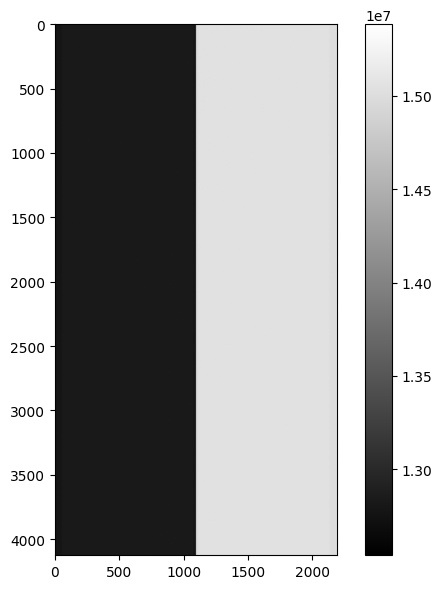

In [5]:
mb_res['master_biases'][0].show(cmap='gray')